# AdaLQO: Adaptive Learned Query Optimizer with Shifting Detector

In [1]:
import argparse
import time
import os

import numpy as np
import pandas as pd
import torch
import sys
import AdaLQO.utils as utils
from AdaLQO.utils import plot_res
from AdaLQO.utils import prediction
from AdaLQO.shift_detector import mmd,ws,ks_values_pca

sys.path.insert(0, 'bao_server')
import bao_server.model as bao_model
import copy
import random

# sys.path.append('ShiftHandler')
# from replay_buffer import summarizer

## 1. Load DataSet

### 1.1 load all datasets - queries, plans, latecies

In [2]:
df = utils.load_data("tpc-h_sf10_100")
BATCH_SIZE = 20
data = utils.split_dataset(df, batch_size=BATCH_SIZE, random_state=42)

## 2. Training BAO Model

In [3]:
def init_bao_model(data):
    X, y = utils.get_training_data(data[0][0])

    # TODO:// have_cache_data=False, since Buffer Feature missed. Fix it later
    reg = bao_model.BaoRegression(have_cache_data=False, verbose=False)
    try:
        reg.fit_feature_extractor(X, y)
    except Exception as e:
        print("ERROR:", e)

    reg.fit_model(X, y, seed=42, ada_size=False)
    return reg

## 3. Queries(Plans) Featurization

In [4]:
def embedding_plans(regressor, batch):
    all_plans = []
    for plans in batch["plans"]:
        all_plans.extend(plans)
    trees = regressor._BaoRegression__tree_transform.transform(all_plans)
    return regressor._BaoRegression__net.get_fixed_features(trees)

## 4. Predict Other Group Data & Continual Learning

In [5]:
def cl(regressor, shift_detect, data):
    res = []
    base_data = data[0][0]
    base_embedding = embedding_plans(regressor, base_data)
    pre_data = data[0][0]
    ori_reg = copy.deepcopy(regressor)

    for i, phase in enumerate(data):
        for j, batch in enumerate(phase):
            # Skip  the first batch
            if i+j == 0:
                continue
            cur_embedding = embedding_plans(regressor, batch)
            match shift_detect:
                case "mmd":
                    mmd_score = mmd(cur_embedding, base_embedding)
                    print(i, j, mmd_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if mmd_score > 0.04:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
                case "ks":
                    cur = cur_embedding.cpu().detach().numpy()
                    base = base_embedding.cpu().detach().numpy()
                    ks_score = ks_values_pca(cur, base)
                    print(i, j, ks_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if ks_score.statistic > 0.2:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
                case "ws":
                    cur = cur_embedding.cpu().detach().numpy()
                    base = base_embedding.cpu().detach().numpy()
                    ws_score = ws(cur, base)
                    print(i, j, ws_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if ws_score > 0.5:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
            ori_res = prediction(ori_reg, batch)
            cur_res = prediction(regressor, batch)
            cur_res["base_bao_latency"] = ori_res["bao_latency"]
            res.append(cur_res)
            pre_data = data[i][j]

    return res


def retrain_model(base_embedding, pre_data, regressor):
    base_data = pre_data
    X, y = utils.get_training_data(base_data)
    try:
        regressor.fit_feature_extractor(X, y)
    except Exception as e:
        print("ERROR:", e)
    regressor.fit_model(X, y, seed=42, ada_size=False)
    base_embedding = embedding_plans(regressor, base_data)
    return base_embedding


## 5. Maximum Mean Discrepancy (MMD)

0 1 tensor(0.1119, device='cuda:0', grad_fn=<AddBackward0>)
0 2 tensor(0.1993, device='cuda:0', grad_fn=<AddBackward0>)
0 3 tensor(0.1195, device='cuda:0', grad_fn=<AddBackward0>)
0 4 tensor(0.0726, device='cuda:0', grad_fn=<AddBackward0>)
0 5 tensor(0.0777, device='cuda:0', grad_fn=<AddBackward0>)
0 6 tensor(0.0398, device='cuda:0', grad_fn=<AddBackward0>)
0 7 tensor(0.0063, device='cuda:0', grad_fn=<AddBackward0>)
0 8 tensor(0.1015, device='cuda:0', grad_fn=<AddBackward0>)
0 9 tensor(0.0454, device='cuda:0', grad_fn=<AddBackward0>)
0 10 tensor(0.1155, device='cuda:0', grad_fn=<AddBackward0>)
0 11 tensor(0.0576, device='cuda:0', grad_fn=<AddBackward0>)
0 12 tensor(0.1111, device='cuda:0', grad_fn=<AddBackward0>)
0 13 tensor(0.0527, device='cuda:0', grad_fn=<AddBackward0>)
0 14 tensor(0.0470, device='cuda:0', grad_fn=<AddBackward0>)
0 15 tensor(0.0302, device='cuda:0', grad_fn=<AddBackward0>)
0 16 tensor(0.0078, device='cuda:0', grad_fn=<AddBackward0>)
0 17 tensor(0.1104, device='cuda:

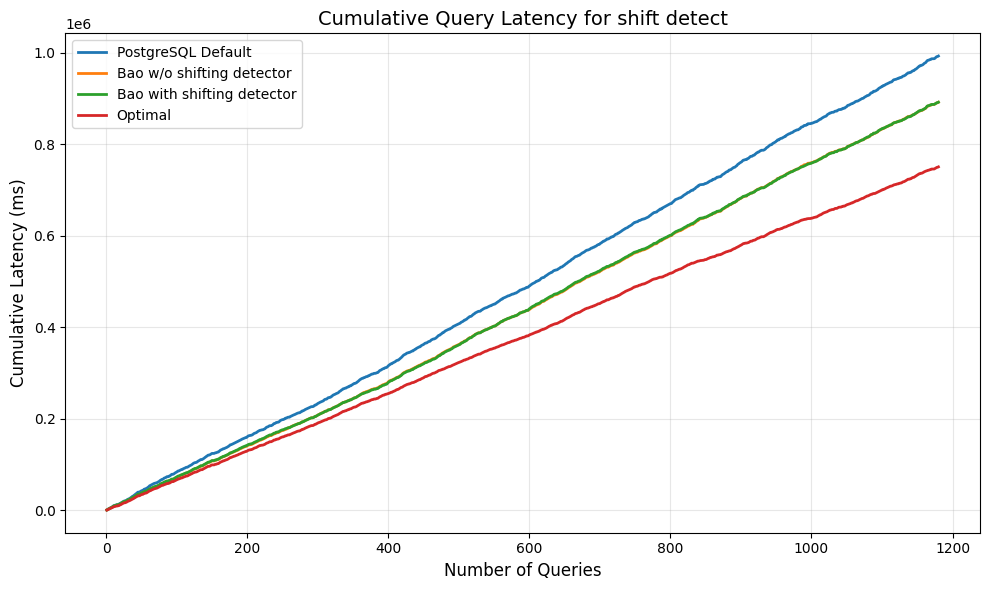

In [6]:
reg = init_bao_model(data)
res = cl(reg,"mmd",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/prototype/outdate/performance_100_mmd.png")

### Relationship of MMD score & Regret

## 7. Kolmogorov-Smirnov (KS) test

0 1 KstestResult(statistic=0.026923076923076925, pvalue=0.7339380171863832)
0 2 KstestResult(statistic=0.036153846153846154, pvalue=0.3635252865203129)
0 3 KstestResult(statistic=0.025384615384615384, pvalue=0.7965686532973193)
1 0 KstestResult(statistic=0.052307692307692305, pvalue=0.05703712748374644)
1 1 KstestResult(statistic=0.09076923076923077, pvalue=4.4135638307896966e-05)
1 2 KstestResult(statistic=0.06076923076923077, pvalue=0.01642858688125664)
1 3 KstestResult(statistic=0.06923076923076923, pvalue=0.003925713063157619)
2 0 KstestResult(statistic=0.1, pvalue=4.445657650641109e-06)
2 1 KstestResult(statistic=0.09846153846153846, pvalue=6.6194175213824905e-06)
2 2 KstestResult(statistic=0.12461538461538461, pvalue=3.2673123459219974e-09)
2 3 KstestResult(statistic=0.11153846153846154, pvalue=1.8417594054754138e-07)


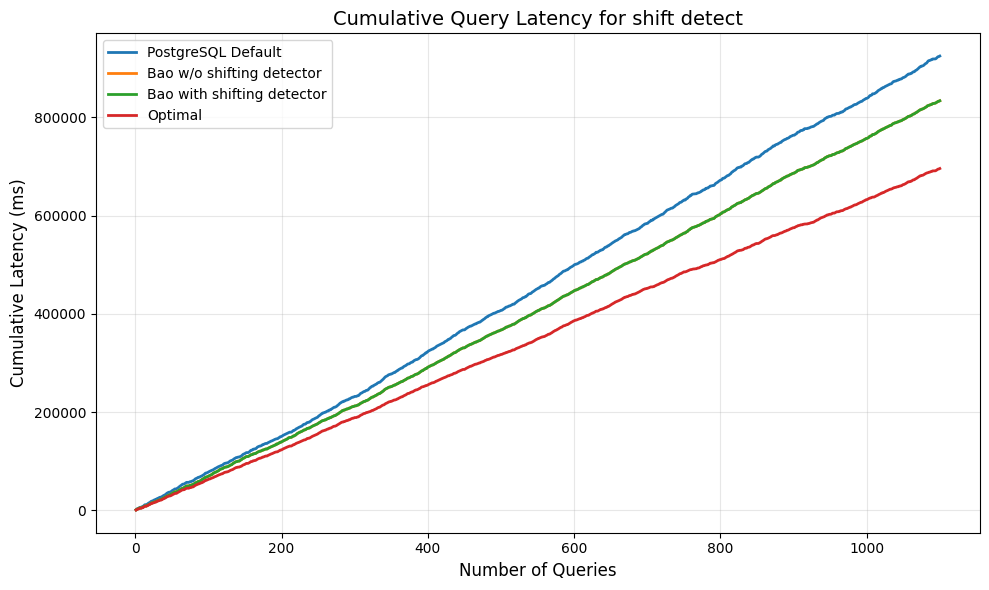

In [17]:
reg = init_bao_model(data)
res = cl(reg,"ks",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/prototype/outdate/performance_100_ks.png")

### KL-Divergence Or JSD vs Regrets (Optional)

## 9. Wassertein Distance vs Regrets

0 1 0.052397224444609466
0 2 0.07371055974410123
0 3 0.059200376363900964
1 0 0.1497597473859787
1 1 0.21542285263538366
1 2 0.12778272523329803
1 3 0.08462690738531262
2 0 0.5379892113575568
2 1 0.10959417178080631
2 2 0.06902787318596473
2 3 0.07121069651383617


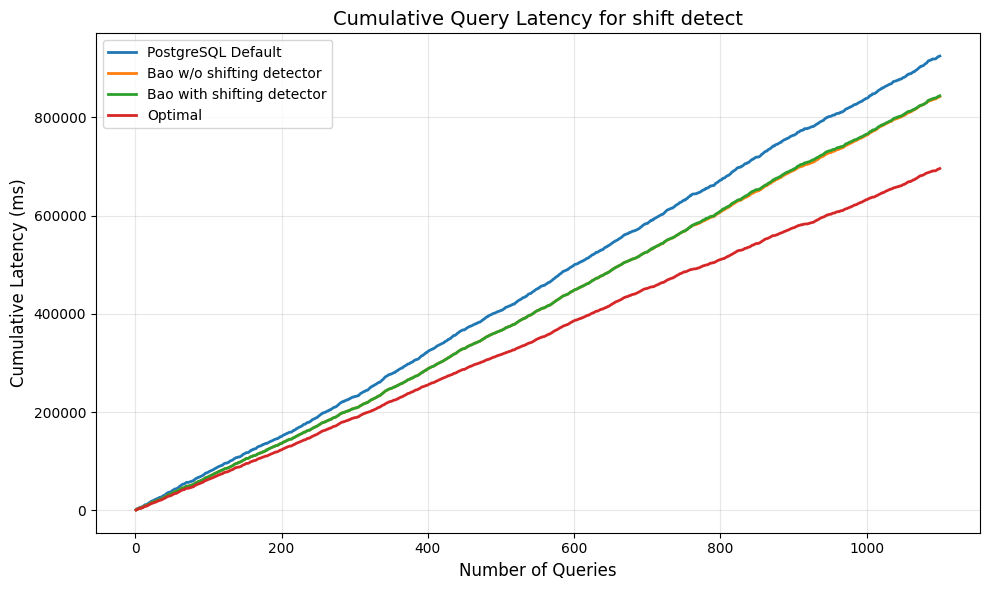

In [18]:
reg = init_bao_model(data)
res = cl(reg,"ws",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/prototype/outdate/performance_10_ws.png")

Therefore, I recommend using the following main figures for the final paper:

Normalized Latency (Default/Bao/Optimal) ← Main Figure

Regret vs Phase ← Core Results

MMD Score + Retrain Point ← Method Validation

Top-1 Accuracy ← Auxiliary Results

These four figures should be sufficient to fully support the experimental section of the entire Continual LQO paper.
因此我建议最终论文主图用：
Normalized Latency (Default/Bao/Optimal) ← 主图
Regret vs Phase ← 核心结果
MMD Score + Retrain Point ← 方法验证
Top-1 Accuracy ← 辅助结果
这四张图基本就能完整支撑整个 Continual LQO 论文的实验部分。